# U6 — Probability & Statistics (Part 2): Lab

**Probability & Information Theory** — axioms · conditional probability · Bayes · distributions · entropy · KL divergence & mutual information

_Day 3 · Phase B — Mathematical Foundations · Built from Module 1.4 + 2.2 (finishing U6)_

#objectives

By the end of this lab you will be able to:

Estimate probabilities by simulation and apply the basic probability rules

Compute conditional probabilities and test for independence

Apply Bayes' theorem to a real-world (medical-test / spam) scenario

Simulate and plot the Bernoulli, Poisson and Gaussian distributions with SciPy

Compute entropy, KL divergence and mutual information, and interpret them

#how to use this lab

Each section has two kinds of cells:

Worked demo cells — run them top to bottom and read the comments to learn the pattern.

LAB EXERCISE cells (marked 🧪) — your turn. Replace each `# YOUR CODE HERE` with working code.

Run cells with **Shift + Enter**. Run the demos before attempting the exercises.

In [1]:
# Core imports for the whole lab
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


#1. Probability theory & axioms

In [2]:
# -----------------------------------------------------------
# 🔹 1A. PROBABILITY BY SIMULATION
# -----------------------------------------------------------

# P(A) = favourable outcomes / total outcomes.
# We can estimate it by simulating many trials.
rolls = np.random.randint(1, 7, size=100_000)   # 100k dice rolls
print(rolls)
p_even = (rolls % 2 == 0).mean()       # P(even)
p_gt4  = (rolls > 4).mean()            # P(roll > 4)
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

[4 5 3 ... 4 1 4]
P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [3]:
# -----------------------------------------------------------
# 🔹 1B. THE ADDITION RULE (disjoint events)
# -----------------------------------------------------------

# Rolling a 1 OR a 2 — these events can't both happen (disjoint)
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


#### 🧪 LAB EXERCISE 1 — Probability by simulation

Simulate flipping **two coins** 100,000 times (`0 = tails, 1 = heads`):
1. Estimate `P(both heads)`.
2. Estimate `P(at least one head)`.
3. Check the addition idea: does `P(0 heads) + P(1 head) + P(2 heads)` sum to 1?

In [7]:
flips = np.random.randint(0, 2, size=(100_000, 2))   # 100k pairs of flips
heads = flips.sum(axis=1)   # number of heads in each pair: 0, 1 or 2

# 1. P(both heads)  -> heads == 2
# YOUR CODE HERE
P_both_heads = (heads == 2).mean()
print('P(both heads) ~', round(P_both_heads, 3), ' (true 0.25)')



# 2. P(at least one head)  -> heads >= 1
# YOUR CODE HERE
P_at_least_one_head = (heads >= 1).mean()
print('P(at least one head) ~', round(P_at_least_one_head, 3), ' (true 0.67)')

# 3. Do P(0) + P(1) + P(2) sum to 1?
# YOUR CODE HERE
P_0 = (heads == 0).mean()
P_1 = (heads == 1).mean()
P_2 = (heads == 2).mean()
print( round(P_0 + P_1 + P_2, 3))


P(both heads) ~ 0.249  (true 0.25)
P(at least one head) ~ 0.749  (true 0.67)
1.0


#2. Conditional probability & independence

In [5]:
# -----------------------------------------------------------
# 🔹 2A. CONDITIONAL PROBABILITY  P(A | B) = P(A and B) / P(B)
# -----------------------------------------------------------

rolls = np.random.randint(1, 7, size=100_000)

# P(roll is 6 | roll is even):  narrow the world to even rolls
even = rolls[rolls % 2 == 0]          # condition on 'even'
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.332  (true 1/3)


In [6]:
# -----------------------------------------------------------
# 🔹 2B. TESTING FOR INDEPENDENCE
# -----------------------------------------------------------

# Two events are independent if P(A|B) == P(A).
# 'roll > 3' and 'roll is even' -> are they independent?
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


#### 🧪 LAB EXERCISE 2 — Conditional probability

Using fresh dice rolls:
1. Estimate `P(roll is odd | roll < 4)`.
2. Estimate `P(roll < 4)` overall.
3. Are the events 'roll is odd' and 'roll < 4' independent? Compare `P(odd|<4)` with `P(odd)`.

In [8]:
rolls = np.random.randint(1, 7, size=100_000)

# 1. P(odd | roll < 4)  -> condition on rolls < 4, then check odd
# YOUR CODE HERE
odd = rolls % 2 == 1
p_odd_given_lt4 = odd[rolls < 4].mean()
print('P(odd | <4) ~', round(p_odd_given_lt4, 3), ' (true 0.33)')


# 2. P(roll < 4)
# YOUR CODE HERE
p_lt4 = (rolls < 4).mean()
print('P(<4) ~', round(p_lt4, 3), ' (true 0.33)')


# 3. Compare P(odd | <4) with P(odd) overall — independent?
# YOUR CODE HERE
p_odd = odd.mean()
print('Independent?', np.isclose(p_odd, p_odd_given_lt4, atol=0.02))


P(odd | <4) ~ 0.668  (true 0.33)
P(<4) ~ 0.501  (true 0.33)
Independent? False


#3. Bayes' theorem

**P(A | B) = P(B | A) · P(A) / P(B)** — update your belief in A after seeing evidence B.

In [9]:
# -----------------------------------------------------------
# 🔹 3A. THE MEDICAL-TEST PROBLEM (by formula)
# -----------------------------------------------------------

# Disease affects 1% of people; test is 99% accurate.
p_disease   = 0.01                       # prior  P(D)
p_pos_given_D  = 0.99                     # true positive rate  P(+|D)
p_pos_given_nD = 0.01                     # false positive rate P(+|not D)

# P(+) = P(+|D)P(D) + P(+|notD)P(notD)   (total probability)
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [10]:
# -----------------------------------------------------------
# 🔹 3B. THE SAME ANSWER BY SIMULATION (sanity check)
# -----------------------------------------------------------

N = 1_000_000
has_disease = np.random.rand(N) < p_disease
# test result depends on disease status
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,    # sick -> 99% positive
                     np.random.rand(N) < p_pos_given_nD)   # healthy -> 1% positive

among_positive = has_disease[tests_pos]      # of those who tested positive...
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.506


#### 🧪 LAB EXERCISE 3 — A Bayes scenario (spam filter)

A spam filter: **20%** of email is spam. The word *"free"* appears in **60%** of spam but only **5%** of real email. An email contains *"free"* — what's `P(spam | "free")`?
1. Write down the prior, likelihood and false-positive rate.
2. Compute `P("free")` with the total-probability rule.
3. Apply Bayes to get `P(spam | "free")`.

In [11]:
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

# 2. P('free') via total probability
# YOUR CODE HERE
p_free = p_free_given_spam * p_spam + p_free_given_ham * (1 - p_spam)
print('P("free") ~', round(p_free, 3), ' (true 0.15)')


# 3. Bayes: P(spam | 'free')
# YOUR CODE HERE
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print('P(spam | "free") ~', round(p_spam_given_free, 3), ' (true 0.33)')


P("free") ~ 0.16  (true 0.15)
P(spam | "free") ~ 0.75  (true 0.33)


#4. Probability distributions

In [12]:
# -----------------------------------------------------------
# 🔹 4A. BERNOULLI & POISSON (discrete)
# -----------------------------------------------------------

# Bernoulli: a single yes/no trial with probability p
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')


# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.304 (true 0.3)
Poisson(4) mean ~ 3.961 (true 4)


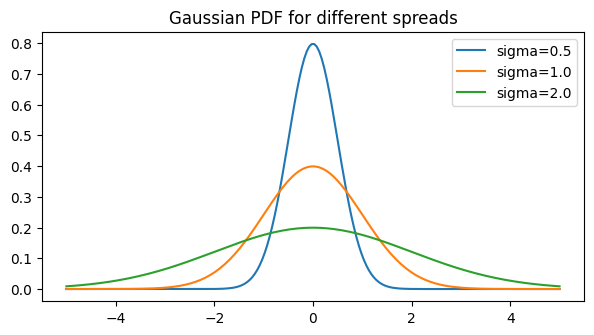

In [13]:
# -----------------------------------------------------------
# 🔹 4B. THE GAUSSIAN (normal) — plot the bell curve
# -----------------------------------------------------------

x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

#### 🧪 LAB EXERCISE 4 — Simulate & plot distributions

1. Draw 10,000 samples from a **Poisson** with `mu=2` and print the sample mean.
2. Plot a **histogram** of those samples.
3. Plot the **Gaussian PDF** for `mu=0` with two different sigmas on one chart and observe how the spread changes the curve.

Poisson(2) mean ~ 1.979 (true 2)


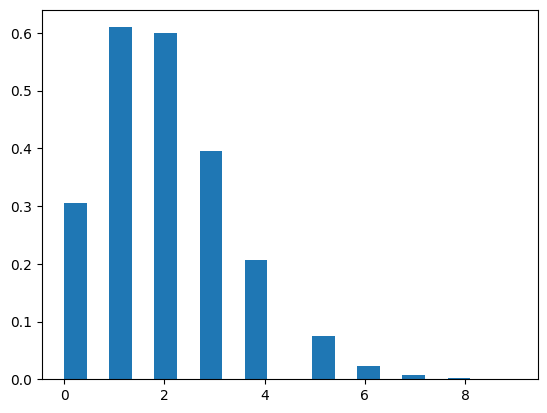

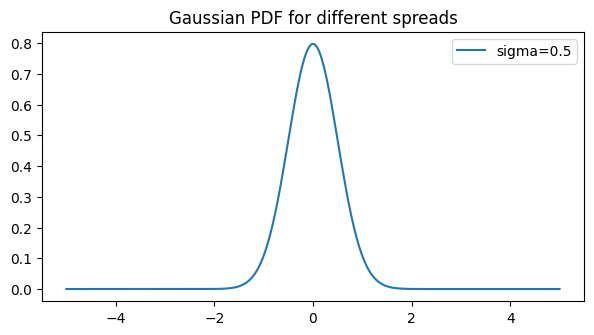

In [14]:
# 1. Poisson(mu=2) samples + mean
# YOUR CODE HERE
pois = stats.poisson(mu=2).rvs(size=10_000)
print('Poisson(2) mean ~', round(pois.mean(), 3), '(true 2)')



# 2. histogram of the samples  (plt.hist(...))
# YOUR CODE HERE
plt.hist(pois, bins=20, density=True)
plt.show()

# 3. Gaussian PDF for two sigmas on one plot
# YOUR CODE HERE
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
    ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()


#5. Entropy, KL divergence & mutual information

In [15]:
# -----------------------------------------------------------
# 🔹 5A. ENTROPY — how uncertain is a distribution?
# -----------------------------------------------------------

from scipy.stats import entropy

fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all

# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [16]:
# -----------------------------------------------------------
# 🔹 5B. KL DIVERGENCE — how far is Q from P?
# -----------------------------------------------------------

P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [17]:
# -----------------------------------------------------------
# 🔹 5C. MUTUAL INFORMATION — which feature is most informative?
# -----------------------------------------------------------

from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


#### 🧪 LAB EXERCISE 5 — Information theory

1. Compute the entropy (in bits) of a fair **4-sided die** and a fair **6-sided die**. Which is more uncertain?
2. Compute the KL divergence `D(P || Q)` for `P = [0.7, 0.3]` and `Q = [0.5, 0.5]`.
3. From the iris MI scores above, name the **most** and **least** informative feature.

In [19]:
fair_4 = [1/4]*4
fair_6 = [1/6]*6
print('Entropy fair 4-sided die   :', round(entropy(fair_4, base=2), 3), 'bits')
print('Entropy fair 6-sided die   :', round(entropy(fair_6, base=2), 3), 'bits')


# 2. KL divergence D(P || Q)
P = np.array([0.7, 0.3]); Q = np.array([0.5, 0.5])
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')


# 3. Most / least informative iris feature (from 5C)
# Most informative: petal length (cm)   Least informative: sepal width (cm)

Entropy fair 4-sided die   : 2.0 bits
Entropy fair 6-sided die   : 2.585 bits
D(P || Q) = 0.119 bits


#📘 Summary — Probability & Information Theory toolkit

| Concept | What it tells you | Key calls |
| ------- | ----------------- | --------- |
| **Probability** | how likely an event is | simulate + `.mean()` |
| **Conditional** | likelihood given other info | filter, then `.mean()` |
| **Bayes** | update belief with evidence | `P(B\|A)P(A)/P(B)` |
| **Distributions** | shapes of randomness | `stats.bernoulli/poisson/norm` |
| **Entropy** | uncertainty (bits) | `scipy.stats.entropy(p, base=2)` |
| **KL divergence** | distance between distributions | `entropy(P, Q)` |
| **Mutual information** | feature informativeness | `mutual_info_classif` |

**Homework (self-paced):** 3 conditional/independent-event problems · a Bayes scenario · simulate & plot 3 distributions · entropy of 3 datasets · KL + MI and rank features.

**Phase B complete!** Next is **Phase C — Data Engineering & Preparation** (U7: Data Science Lifecycle & data sources).